Encoding in python

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import OneHotEncoder

In [2]:
wine = load_wine()
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [4]:
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
print(df.iloc[[25, 75, 150]].T)

                                 25      75      150
alcohol                        13.05   11.66   13.50
malic_acid                      2.05    1.88    3.12
ash                             3.22    1.92    2.62
alcalinity_of_ash              25.00   16.00   24.00
magnesium                     124.00   97.00  123.00
total_phenols                   2.63    1.61    1.40
flavanoids                      2.68    1.57    1.57
nonflavanoid_phenols            0.47    0.34    0.22
proanthocyanins                 1.92    1.15    1.25
color_intensity                 3.58    3.80    8.60
hue                             1.13    1.23    0.59
od280/od315_of_diluted_wines    3.20    2.14    1.30
proline                       830.00  428.00  500.00
target                          0.00    1.00    2.00


Conversione delle classi

In [5]:
# conversione dei valori numerici in stringhe target
df["target"] = df["target"].map({ 0: "class_0", 1: "class_1", 2: "class_2"})
print(df.iloc[[25, 75, 150]].T)


                                  25       75       150
alcohol                         13.05    11.66     13.5
malic_acid                       2.05     1.88     3.12
ash                              3.22     1.92     2.62
alcalinity_of_ash                25.0     16.0     24.0
magnesium                       124.0     97.0    123.0
total_phenols                    2.63     1.61      1.4
flavanoids                       2.68     1.57     1.57
nonflavanoid_phenols             0.47     0.34     0.22
proanthocyanins                  1.92     1.15     1.25
color_intensity                  3.58      3.8      8.6
hue                              1.13     1.23     0.59
od280/od315_of_diluted_wines      3.2     2.14      1.3
proline                         830.0    428.0    500.0
target                        class_0  class_1  class_2


1. One Hot Encoding

In [6]:
# creazione dell'encoder
encoder = OneHotEncoder(sparse_output=False)
encoder_ohe = encoder.fit_transform(df[["target"]])
ohe_cols = encoder.get_feature_names_out(["target"])

# creazione del df con le nuove colonne del ohe
df_ohe = pd.concat([df, pd.DataFrame(encoder_ohe, columns=ohe_cols)], axis=1)
print(df_ohe.iloc[[25, 75, 150]].T)


                                  25       75       150
alcohol                         13.05    11.66     13.5
malic_acid                       2.05     1.88     3.12
ash                              3.22     1.92     2.62
alcalinity_of_ash                25.0     16.0     24.0
magnesium                       124.0     97.0    123.0
total_phenols                    2.63     1.61      1.4
flavanoids                       2.68     1.57     1.57
nonflavanoid_phenols             0.47     0.34     0.22
proanthocyanins                  1.92     1.15     1.25
color_intensity                  3.58      3.8      8.6
hue                              1.13     1.23     0.59
od280/od315_of_diluted_wines      3.2     2.14      1.3
proline                         830.0    428.0    500.0
target                        class_0  class_1  class_2
target_class_0                    1.0      0.0      0.0
target_class_1                    0.0      1.0      0.0
target_class_2                    0.0      0.0  

2. Dummy Coding

In [7]:
encoded_dummy = pd.get_dummies(df["target"], drop_first=True, dtype=int)
# questo metodo prende il primo valore e lo prende come riferimento, prendendo come k-1 colonne
df_dummy = pd.concat([df, encoded_dummy], axis=1)
print(df_dummy.iloc[[25, 75, 150]].T)

                                  25       75       150
alcohol                         13.05    11.66     13.5
malic_acid                       2.05     1.88     3.12
ash                              3.22     1.92     2.62
alcalinity_of_ash                25.0     16.0     24.0
magnesium                       124.0     97.0    123.0
total_phenols                    2.63     1.61      1.4
flavanoids                       2.68     1.57     1.57
nonflavanoid_phenols             0.47     0.34     0.22
proanthocyanins                  1.92     1.15     1.25
color_intensity                  3.58      3.8      8.6
hue                              1.13     1.23     0.59
od280/od315_of_diluted_wines      3.2     2.14      1.3
proline                         830.0    428.0    500.0
target                        class_0  class_1  class_2
class_1                             0        1        0
class_2                             0        0        1


3. Effect Coding

In [8]:
effect = pd.get_dummies(df["target"], dtype=int)

reference_col = "class_0"
effect[reference_col] = effect[reference_col].replace(1, -1)

df_effect = pd.concat([df, effect], axis=1)

print(df_effect.iloc[[25, 75, 150]].T)

                                  25       75       150
alcohol                         13.05    11.66     13.5
malic_acid                       2.05     1.88     3.12
ash                              3.22     1.92     2.62
alcalinity_of_ash                25.0     16.0     24.0
magnesium                       124.0     97.0    123.0
total_phenols                    2.63     1.61      1.4
flavanoids                       2.68     1.57     1.57
nonflavanoid_phenols             0.47     0.34     0.22
proanthocyanins                  1.92     1.15     1.25
color_intensity                  3.58      3.8      8.6
hue                              1.13     1.23     0.59
od280/od315_of_diluted_wines      3.2     2.14      1.3
proline                         830.0    428.0    500.0
target                        class_0  class_1  class_2
class_0                            -1        0        0
class_1                             0        1        0
class_2                             0        0  

4. Visualizzazione encodind

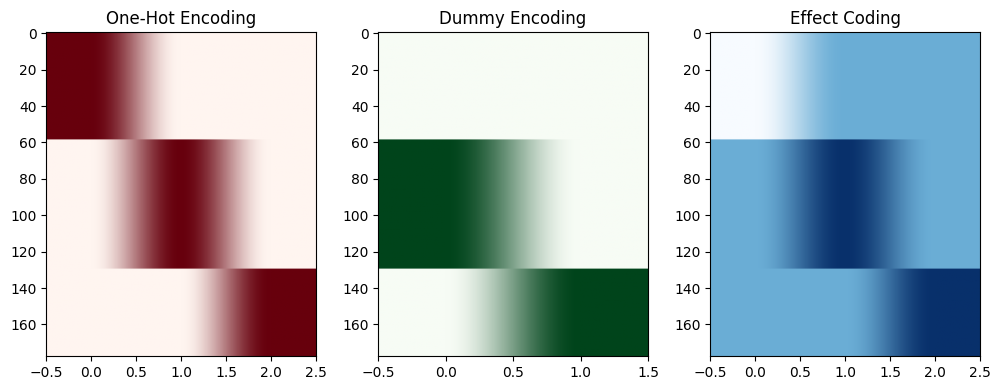

In [9]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(df_ohe[ohe_cols].values, cmap="Reds", aspect="auto")
plt.title("One-Hot Encoding")

plt.subplot(1, 3, 2)
plt.imshow(df_dummy[encoded_dummy.columns].values, cmap="Greens", aspect="auto")
plt.title("Dummy Encoding")

plt.subplot(1, 3, 3)
plt.imshow(df_effect[["class_0", "class_1", "class_2"]], cmap="Blues", aspect="auto")
plt.title("Effect Coding") 

plt.tight_layout()
plt.show()
